# Evaluation of distribution of models on CORDEX-ML_BENCH datasets

In [1]:
%reload_ext autoreload

%autoreload 2

%reload_ext dotenv
%dotenv

In [2]:
from mlde_analysis.furflex_default_params import *

In [3]:
import functools
import math
import string

import IPython
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from mlde_analysis import plot_map, SUBREGIONS, BOX_LOCATIONS
from mlde_analysis.display import pretty_table, VAR_RANGES
from mlde_analysis.distribution import mean_bias, std_bias, stat_bias, plot_freq_density, plot_distribution_figure, compute_metrics, DIST_THRESHOLDS, plot_freq_density_figure
from mlde_analysis.wet_dry import threshold_exceeded_prop_stats, threshold_exceeded_prop, threshold_exceeded_prop_error, threshold_exceeded_prop_change, plot_threshold_exceedence_errors, THRESHOLDS, wd_mean, wd_mean_bias
from mlde_utils import cp_model_rotated_pole
from mlde_analysis import qq_plot, reasonable_quantiles

In [4]:
matplotlib.rcParams['figure.dpi'] = 300

In [5]:
IPython.display.Markdown(desc)


Describe in more detail the models being compared


In [6]:
%reload_ext mlde_analysis.magics 
EVAL_DS, MODELS, TARGET_DAS, PRED_DAS, VAR_DAS, MODELLABEL2SPEC = %load_eval_data
EVAL_DS["CPM"].sel(ensemble_member=["r001i1p00000"])

/home/vf20964/furflex/code/mlde-analysis/.pixi/envs/default/lib/python3.12/site-packages/xarray/core/variable.py:2453: PerformanceWarning: Adding/subtracting object-dtype array to TimedeltaArray not vectorized.
  f(self_data, other_data) if not reflexive else f(other_data, self_data)
/home/vf20964/furflex/code/mlde-analysis/.pixi/envs/default/lib/python3.12/site-packages/xarray/core/variable.py:2453: PerformanceWarning: Adding/subtracting object-dtype array to TimedeltaArray not vectorized.
  f(self_data, other_data) if not reflexive else f(other_data, self_data)


<xarray.Dataset> Size: 15MB
Dimensions:                     (model: 2, sample_id: 1, ensemble_member: 1,
                                 grid_latitude: 64, grid_longitude: 64,
                                 time: 288, bnds: 2)
Coordinates: (12/14)
  * model                       (model) object 16B 'e0065' 'e0240'
  * ensemble_member             (ensemble_member) object 8B 'r001i1p00000'
  * grid_latitude               (grid_latitude) float64 512B -2.49 ... 2.55
  * grid_longitude              (grid_longitude) float64 512B 357.9 ... 363.0
  * time                        (time) object 2kB 2065-09-01 00:30:00 ... 207...
    latitude                    (grid_latitude, grid_longitude) float64 33kB ...
    ...                          ...
    year                        (time) int32 1kB ...
    yyyymmddhh                  (time) |S64 18kB ...
    time_period                 (time) <U6 7kB 'future' 'future' ... 'future'
    dec_adjusted_year           (time) int64 2kB 2065 2065 2065 ... 2075 2075
    stratum                     (time) <U10 12kB 'future SON' ... 'future JJA'
    tp_season_year              (time) <U15 17kB 'future SON 2065' ... 'futur...
Dimensions without coordinates: sample_id, bnds
Data variables:
    pred_pr                     (model, sample_id, ensemble_member, grid_latitude, grid_longitude, time) float32 9MB ...
    grid_latitude_bnds          (grid_latitude, bnds, time) float64 295kB ...
    grid_longitude_bnds         (grid_longitude, bnds, time) float64 295kB ...
    target_pr                   (ensemble_member, time, grid_latitude, grid_longitude) float32 5MB ...
    rotated_latitude_longitude  (time) float64 2kB ...
    time_bnds                   (time, bnds) object 5kB ...
Attributes:
    grid_mapping:   rotated_latitude_longitude
    standard_name:  pred_pr
    units:          kg m-2 s-1

## Figure: distribution

* Frequency Density Histogram of rainfall intensities
* Maps of Mean bias ($\frac{\mu_{sample}-\mu_{CPM}}{\mu_{CPM}}$) over all samples, time and ensemble members
* Std Dev Bias $\frac{\sigma_{sample}}{\sigma_{CPM}}$ over all samples, time and ensemble members

Table of:

* RMS biases
* J-S Distances
* proportion of density over thresholds

### pr

/home/vf20964/furflex/code/mlde-analysis/src/mlde_analysis/distribution.py:196: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  metrics_ds = xr.merge(


,NaN Count,RMS Mean Bias (kg m-2 s-1),RMS Std Dev Bias (kg m-2 s-1),quantile,RMS Q999 Bias (kg m-2 s-1),Relative RMS Mean Bias (%),Relative RMS Std Dev Bias (%),Relative RMS Q999 Bias (%),J-S distance,Emu > 0.1,Emu > 0.1 - CPM > 0.1,Emu > 25,Emu > 25 - CPM > 25,Emu > 75,Emu > 75 - CPM > 75,Emu > 125,Emu > 125 - CPM > 125
model,,,,,,,,,,,,,,,,,
e0065,0,0.08236,0.312,0.999,2.921,66.02,64.9,65.64,0.07485,0.05632,-0.0374,0,0,0,0,0,0
e0240,0,0.09589,0.3655,0.999,3.419,84.61,79.9,79.28,0.1145,0.02362,-0.0701,0,0,0,0,0,0


8.477105034722222e-07
5e-08


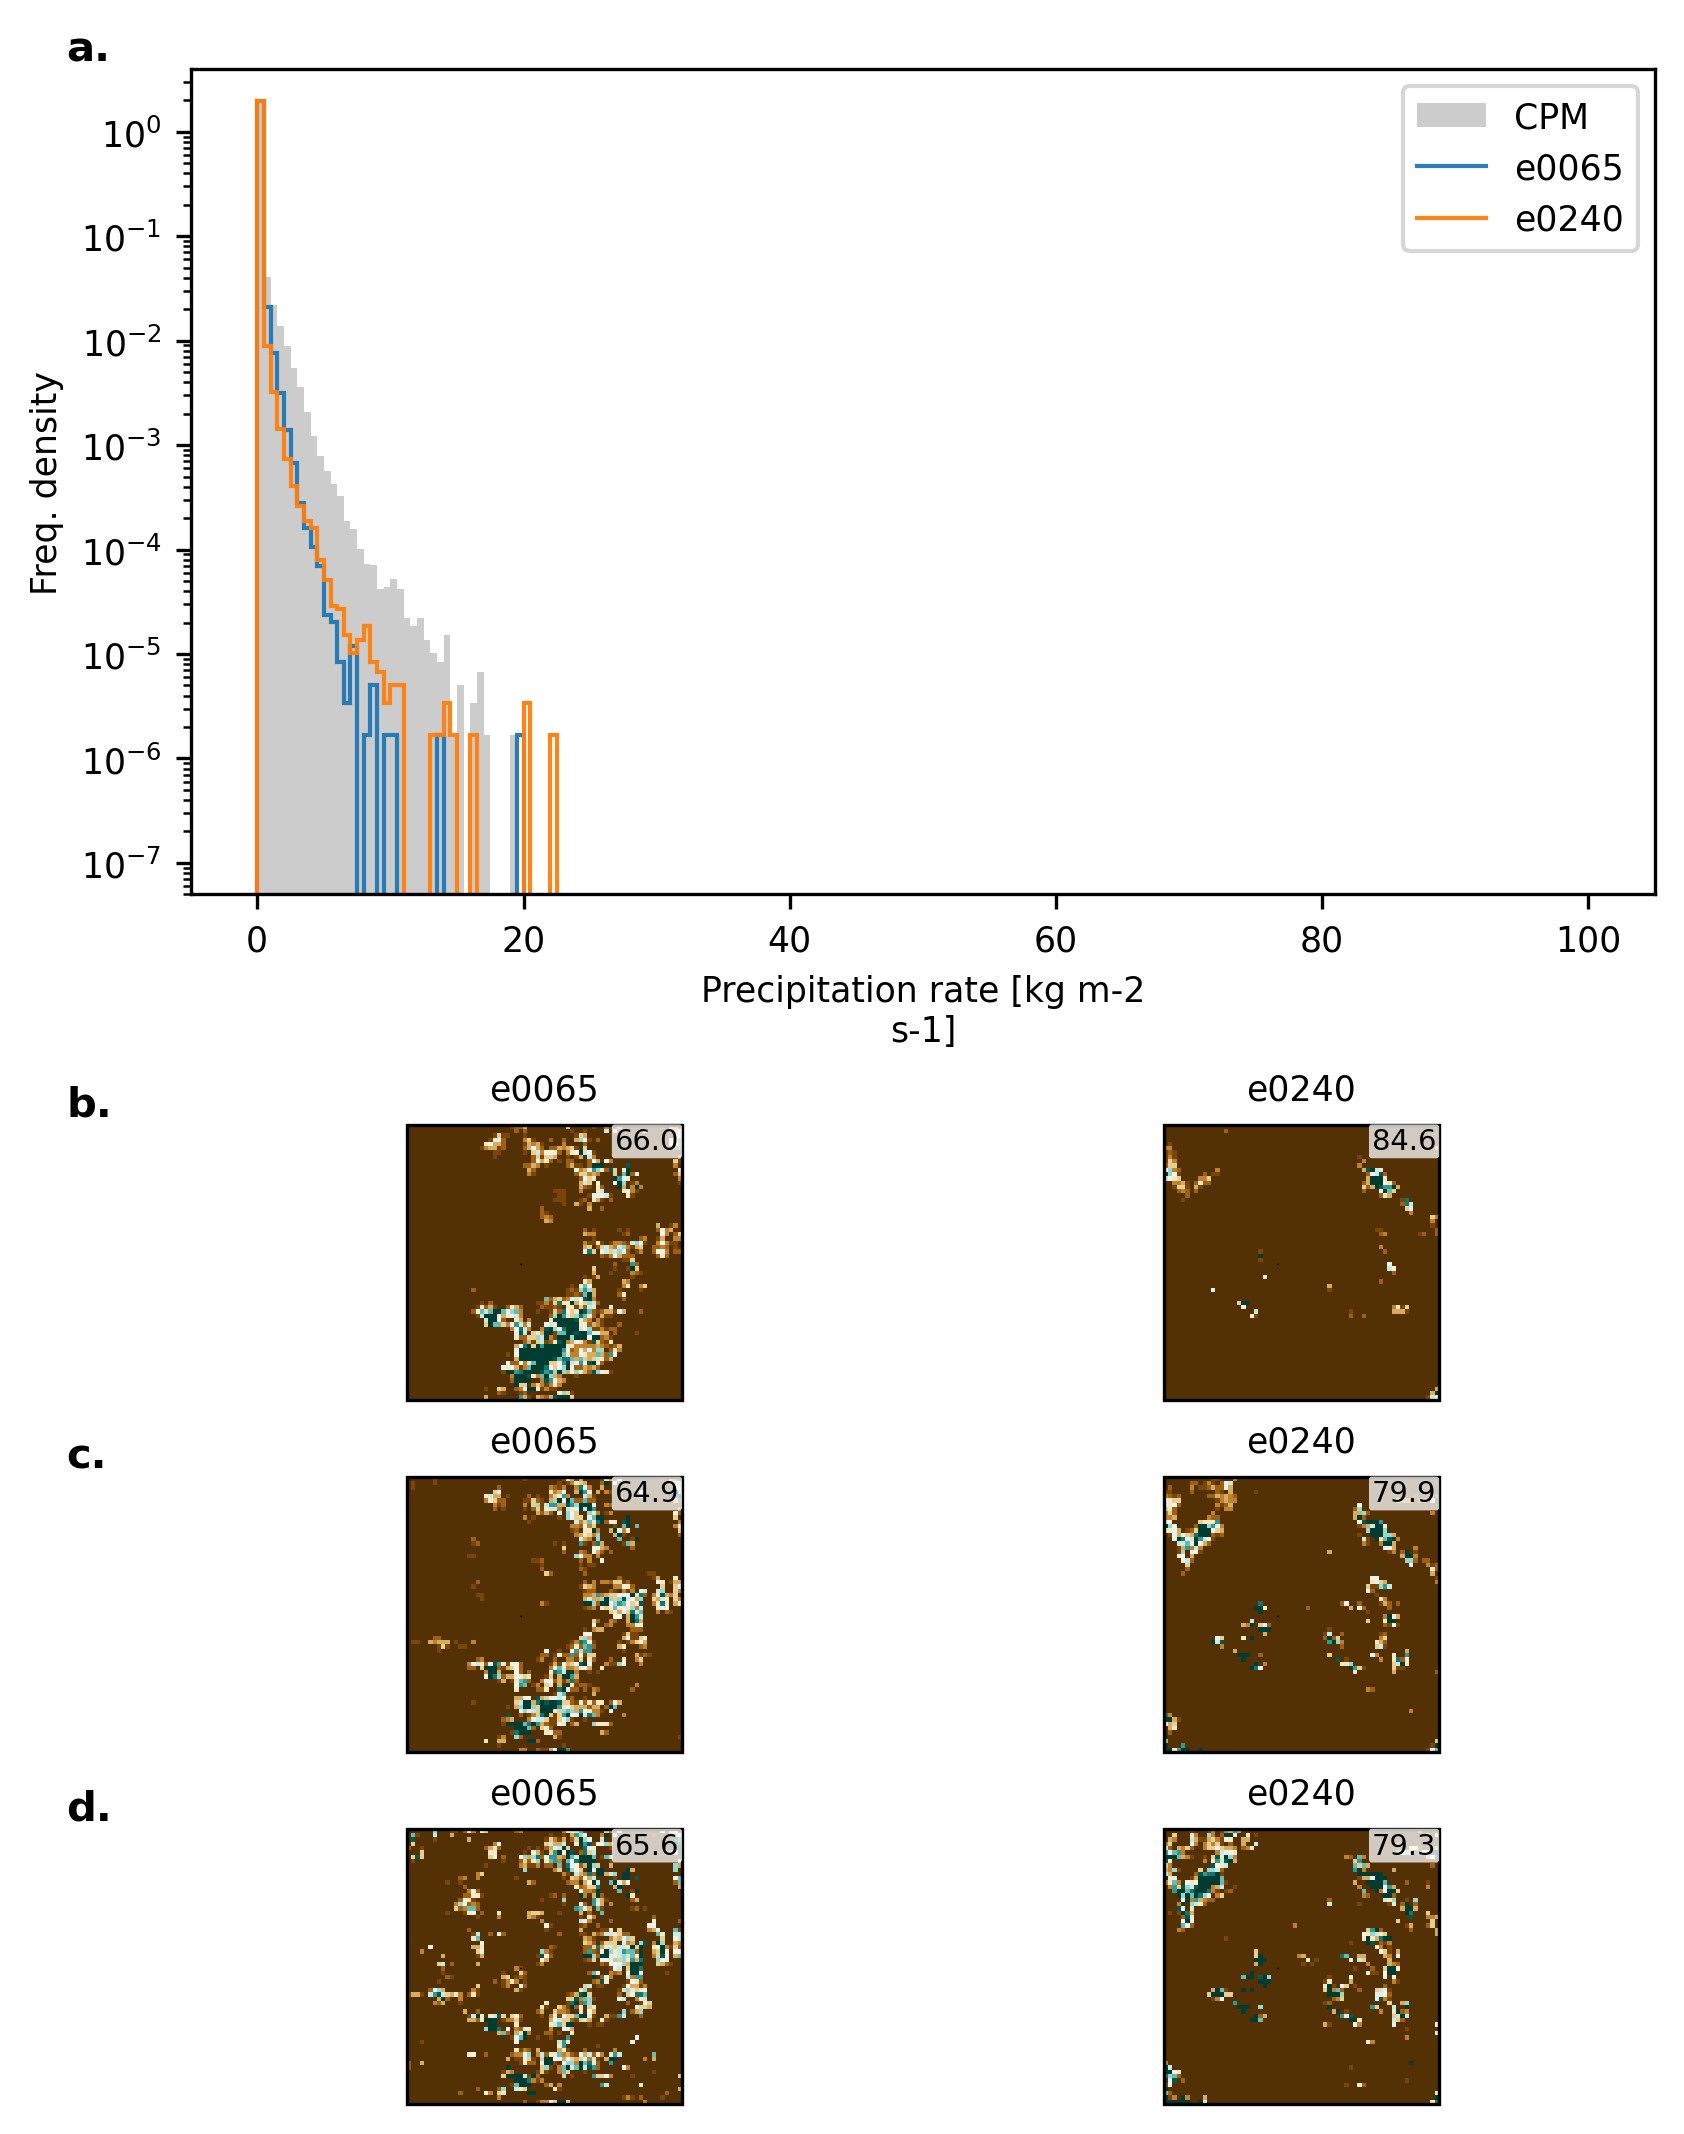

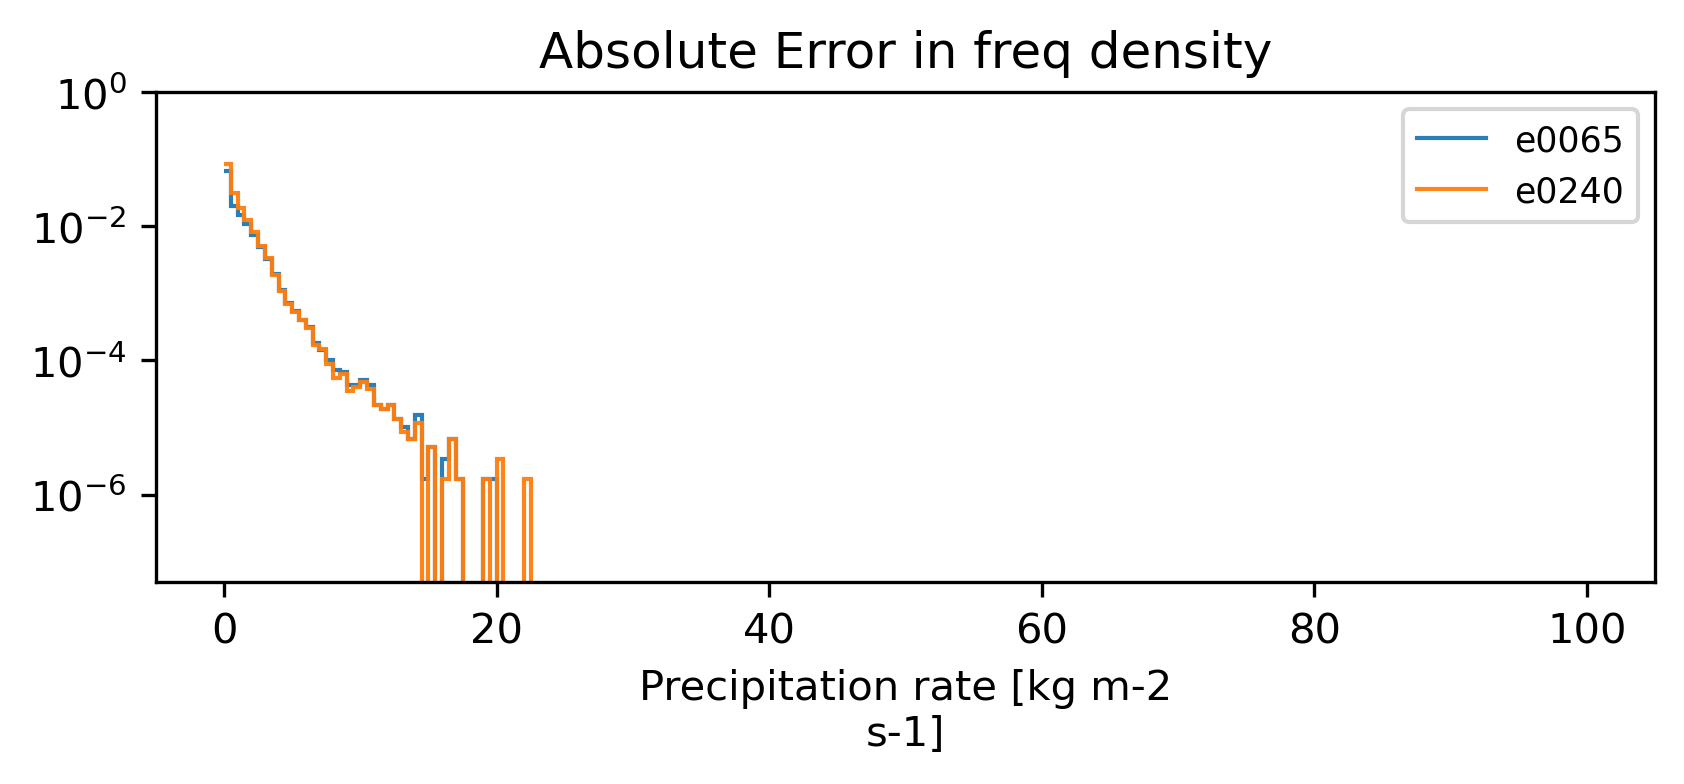

In [8]:
for var in eval_vars:
    IPython.display.display_markdown(f"### {var}", raw=True)
    
    hist_das = PRED_DAS[var]
    target_da = TARGET_DAS[var]
    
    metrics_ds = compute_metrics(hist_das, target_da, thresholds=DIST_THRESHOLDS[var])

    pretty_table(metrics_ds, round=4)
    
    normalize=(var == "pr")
    mean_biases = PRED_DAS[var].groupby("model").map(mean_bias, target_da=target_da, normalize=(var=="pr"))

    std_biases = PRED_DAS[var].groupby("model").map(std_bias, target_da=target_da, normalize=(var=="pr"))
    f_q999_bias = functools.partial(stat_bias, stat_func=functools.partial(xr.DataArray.quantile, q=0.999))
    q999_biases = PRED_DAS[var].groupby("model").map(f_q999_bias, target_da=target_da, normalize=(var=="pr"))
    
    bias_kwargs = {"style": f"{var}Bias"}
    for fd_kwargs in [{"yscale": "log", "target_label": target_sim_key}]:
        fig = plt.figure(layout="constrained", figsize=(5.5, 7))
        error_fig = plt.figure(layout="constrained", figsize=(5.5, 2.5))
        error_axd = error_fig.subplot_mosaic([["Error"]])
        error_ax = error_axd["Error"]
        axd = plot_distribution_figure(
            fig,
            hist_das,
            target_da,
            {"meanb": mean_biases, "stdb": std_biases, "q999b": q999_biases,},
            MODELLABEL2SPEC,
            error_ax=error_ax, hrange=VAR_RANGES[var], fd_kwargs=fd_kwargs, bias_kwargs=bias_kwargs
        )
        if var == "relhum150cm":
            axd["Density"].axvline(x=100, color='k', linestyle='--', linewidth=1)
        
        plt.show()

## QQ plots

### pr

-6


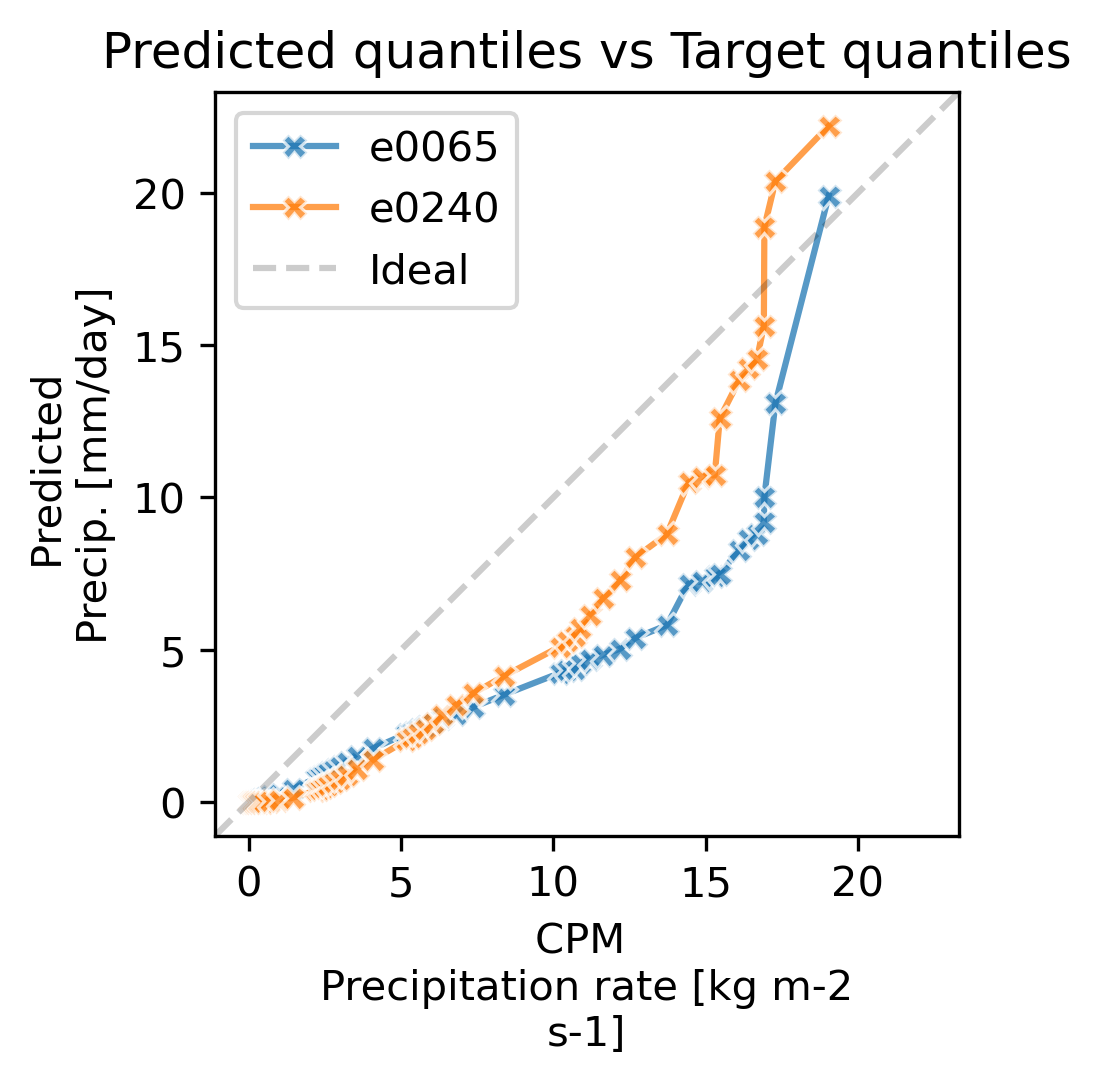

In [9]:
quantile_dims=["ensemble_member", "T", "X", "Y"]

for var in eval_vars:
    IPython.display.display_markdown(f"### {var}", raw=True)

    target_da = TARGET_DAS[var]
    quantiles = reasonable_quantiles(target_da)
    target_quantiles = target_da.cf.quantile(quantiles, dim=quantile_dims).rename("target_q")

    for source, ds in EVAL_DS.items():
        pred_da = ds[f"pred_{var}"]
        pred_quantiles = pred_da.cf.quantile(quantiles, dim=quantile_dims).rename("pred_q")

        layout="constrained"

        fig, ax = plt.subplots(figsize=(3.5, 3.5), layout="constrained")

        xlabel = f"CPM \n{xr.plot.utils.label_from_attrs(da=target_da)}"
        ylabel = f"Predicted \n{xr.plot.utils.label_from_attrs(da=pred_da)}"

        qq_plot(ax, target_quantiles, pred_quantiles, title=f"Predicted quantiles vs Target quantiles", xlabel=xlabel, ylabel=ylabel)

    plt.show()

## Figure: Threshold exceedence

Threshold: 0.1kg m-2 s-1 
 
 
   
   
 % Threshold exceeded 
 
 
 season 
 model 
   
 
 
 
 
 Annual 
 e0065 
 5.6 
 
 
 e0240 
 2.4 
 
 
 CPM 
 9.4 
 
 
 DJF 
 e0065 
 nan 
 
 
 e0240 
 nan 
 
 
 CPM 
 nan 
 
 
 MAM 
 e0065 
 8.4 
 
 
 e0240 
 6.7 
 
 
 CPM 
 13.4 
 
 
 JJA 
 e0065 
 4.0 
 
 
 e0240 
 1.4 
 
 
 CPM 
 9.5 
 
 
 SON 
 e0065 
 5.1 
 
 
 e0240 
 0.7 
 
 
 CPM 
 7.3

#### Threshold: 0.1kg m-2 s-1

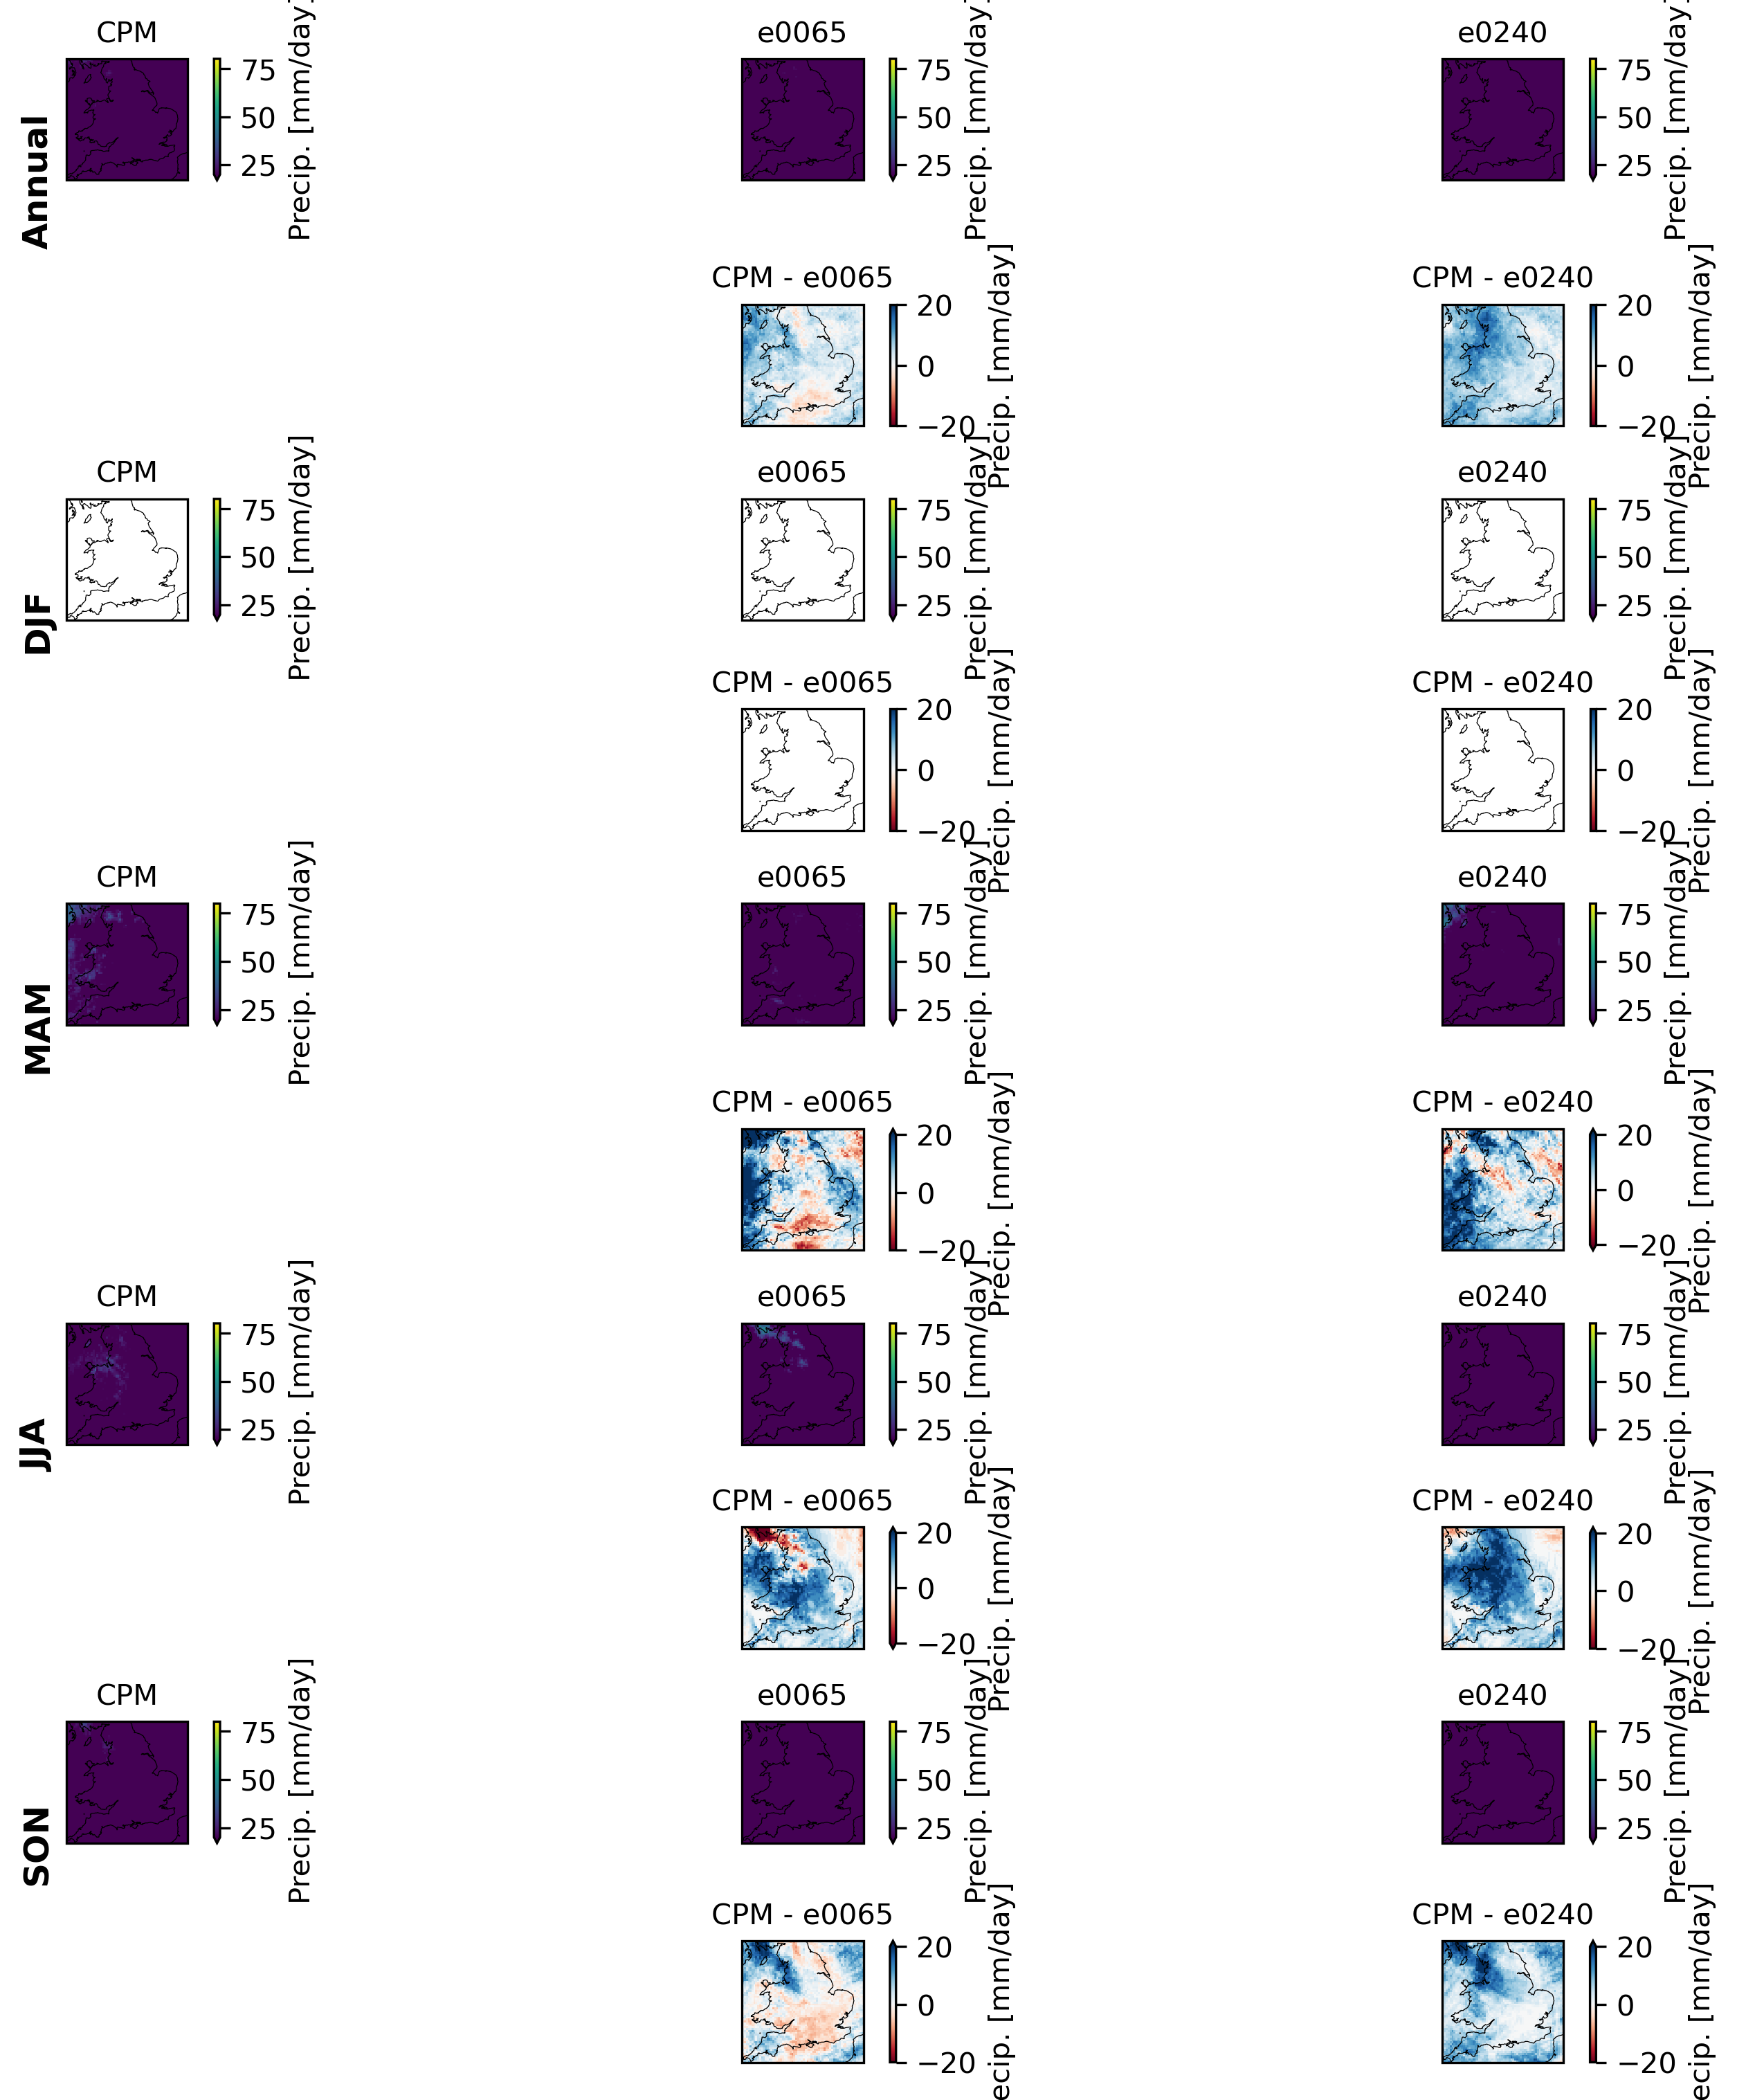

In [10]:
for var, thresholds in THRESHOLDS.items():
    if var in eval_vars:

        target_da = TARGET_DAS[var]
        
        threshold_exceeded_stats = { threshold: threshold_exceeded_prop_stats(VAR_DAS[var][f"pred_{var}"], target_da, threshold) for threshold in thresholds }

        dfs = [threshold_exceeded_stats[threshold].cf.mean(["X", "Y"]).to_dataframe().style.set_table_attributes("style='display:inline'").set_caption(f"Threshold: {threshold}{target_da.attrs['units']}").format(precision=1).to_html() for threshold in thresholds]

        IPython.display.display_html(functools.reduce(lambda v, e: v+e, dfs), raw=True)

        for threshold in thresholds:
            IPython.display.display_markdown(f"#### Threshold: {threshold}{target_da.attrs['units']}", raw=True)

            plot_threshold_exceedence_errors(threshold_exceeded_stats[threshold])

            plt.show()

## Rough: wet-day mean